# MIL + Patch-Level Ensemble

Combines the best **patch-level** model (EfficientNet-B0, kappa 0.8589 on test) with the
best **MIL** model (EfficientNetMIL-B0 with focal loss, val kappa ~0.858) by averaging
their sigmoid probabilities at inference time.

Rationale: the patch model excels at local texture features; the MIL model learns
bag-level context via attention over the 36-patch bag. Their errors are partly
complementary, so averaging should push the ensemble higher.

Also evaluates: patch alone, MIL alone, mean ensemble, weighted ensemble
(weight optimised on validation set).

In [1]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, SequentialSampler
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../../../')
from utils.dataset import PandasDataset
from utils.mil import PandasWithMilDataset, EfficientNetMIL
from utils.models import EfficientNetApi
from utils.metrics import calculate_metrics, format_metrics

In [2]:
SEED = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

BATCH_SIZE_PATCH = 3
BATCH_SIZE_MIL   = 8
NUM_WORKERS      = 4
OUTPUT_CLASSES   = 5
DROPOUT_RATE     = 0.6    # patch model
MIL_DROPOUT      = 0.4    # MIL model
MAX_PATCHES      = 36

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

ROOT_DIR    = '../../..'
DATA_DIR    = '../../../..'
IMAGES_DIR  = os.path.join(DATA_DIR, 'tiles')          # patch images dir
PATCHES_DIR = '/home/woshington/Projects/Doutorado/bag_of_patches'  # bag dir
os.makedirs('logs', exist_ok=True)

Device: cuda


In [3]:
# ── Load models ───────────────────────────────────────────────────────
# Patch-level B0
backbone_patch  = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
patch_model     = EfficientNetApi(model=backbone_patch,
                                  output_dimensions=OUTPUT_CLASSES,
                                  dropout_rate=DROPOUT_RATE)
patch_model.load_state_dict(
    torch.load('models/b0-entropy-ordinal-3-focal.pth', weights_only=True)
)
patch_model = patch_model.to(DEVICE).eval()
print('Patch model loaded')

# MIL B0 (focal loss variant)
backbone_mil = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
mil_model    = EfficientNetMIL(
    model=backbone_mil,
    output_classes=OUTPUT_CLASSES,
    dropout_rate=MIL_DROPOUT,
    hidden_dim=512,
    gated=True,
    pool='att',
)
mil_model.load_state_dict(
    torch.load('../transformers/models/b0-mil-focal.pth', weights_only=True)
)
mil_model = mil_model.to(DEVICE).eval()
print('MIL model loaded')

Patch model loaded
MIL model loaded


In [4]:
# ── Data ─────────────────────────────────────────────────────────────
df_all = pd.read_csv(f'{ROOT_DIR}/data/train_5fold.csv')
df_all.columns = df_all.columns.str.strip()

df_entropy = pd.read_csv(f'{ROOT_DIR}/data/entropy.csv')
hard_ids = set(df_entropy.sort_values('difficulty_score', ascending=False)
                         .head(int(len(df_entropy) * 0.2))['image_id'])
df_all = df_all[~df_all['image_id'].isin(hard_ids)].reset_index(drop=True)

df_val  = df_all[df_all['fold'] == 3].reset_index(drop=True)
df_test = pd.read_csv(f'{ROOT_DIR}/data/test.csv')

# Filter to images that exist in both patch and bag-of-patches dirs
def keep_patch_exists(df):
    return df[df['image_id'].apply(
        lambda x: os.path.isfile(f'{IMAGES_DIR}/{x}.png'))].reset_index(drop=True)

def keep_bag_exists(df):
    return df[df['image_id'].apply(
        lambda x: os.path.isdir(f'{PATCHES_DIR}/{x}'))].reset_index(drop=True)

# Use intersection of images available to both modalities
df_val_patch  = keep_patch_exists(df_val)
df_test_patch = keep_patch_exists(df_test)
df_val_mil    = keep_bag_exists(df_val)
df_test_mil   = keep_bag_exists(df_test)

# Common image IDs for the ensemble evaluation
val_common_ids  = set(df_val_patch['image_id']) & set(df_val_mil['image_id'])
test_common_ids = set(df_test_patch['image_id']) & set(df_test_mil['image_id'])

df_val_common  = df_val_patch[df_val_patch['image_id'].isin(val_common_ids)].reset_index(drop=True)
df_test_common = df_test_patch[df_test_patch['image_id'].isin(test_common_ids)].reset_index(drop=True)

print(f'Val  — patch: {len(df_val_patch)}  MIL: {len(df_val_mil)}  common: {len(df_val_common)}')
print(f'Test — patch: {len(df_test_patch)}  MIL: {len(df_test_mil)}  common: {len(df_test_common)}')

Val  — patch: 1767  MIL: 1767  common: 1767
Test — patch: 1590  MIL: 1590  common: 1590


In [5]:
def get_patch_probs(model, df, images_dir, batch_size, num_workers, device):
    """Run patch model inference. Returns (probs: np.ndarray (N,C), targets: np.ndarray)."""
    ds  = PandasDataset(images_dir, df, transforms=None, format='png')
    dl  = DataLoader(ds, batch_size=batch_size, num_workers=num_workers,
                     sampler=SequentialSampler(ds))
    all_probs, all_targets = [], []
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y, _ in tqdm(dl, desc='Patch inference'):
            probs = torch.sigmoid(model(batch_x.to(device))).cpu()
            all_probs.append(probs)
            all_targets.append(batch_y.sum(1).long())
    return torch.cat(all_probs).numpy(), torch.cat(all_targets).numpy()


def get_mil_probs(model, df, patches_dir, batch_size, num_workers, device):
    """Run MIL model inference. Returns (probs, targets)."""
    ds = PandasWithMilDataset(patches_dir, df, transforms=None, max_patches=MAX_PATCHES)
    dl = DataLoader(ds, batch_size=batch_size, num_workers=num_workers,
                    sampler=SequentialSampler(ds), pin_memory=True)
    all_probs, all_targets = [], []
    model.eval()
    with torch.no_grad():
        for bag, mask, targets, _ in tqdm(dl, desc='MIL inference'):
            bag  = bag.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(bag, mask)
            probs = torch.sigmoid(out['logits']).cpu()
            all_probs.append(probs)
            all_targets.append(targets.sum(1).long())
    return torch.cat(all_probs).numpy(), torch.cat(all_targets).numpy()

print('Inference helpers defined')

Inference helpers defined


In [6]:
# ── Collect val probabilities (for weight search) ────────────────────
val_patch_probs, val_targets  = get_patch_probs(patch_model, df_val_common,
                                                IMAGES_DIR, BATCH_SIZE_PATCH, NUM_WORKERS, DEVICE)
val_mil_probs, val_targets_mil = get_mil_probs(mil_model, df_val_common,
                                               PATCHES_DIR, BATCH_SIZE_MIL, NUM_WORKERS, DEVICE)

assert np.array_equal(val_targets, val_targets_mil), 'Targets mismatch between patch and MIL dataloaders'
print(f'Val probabilities collected. Shape: {val_patch_probs.shape}')

MIL inference: 100%|██████████| 221/221 [01:08<00:00,  3.21it/s]

Val probabilities collected. Shape: (1767, 5)


Best α = 0.40  →  val kappa = 0.8731


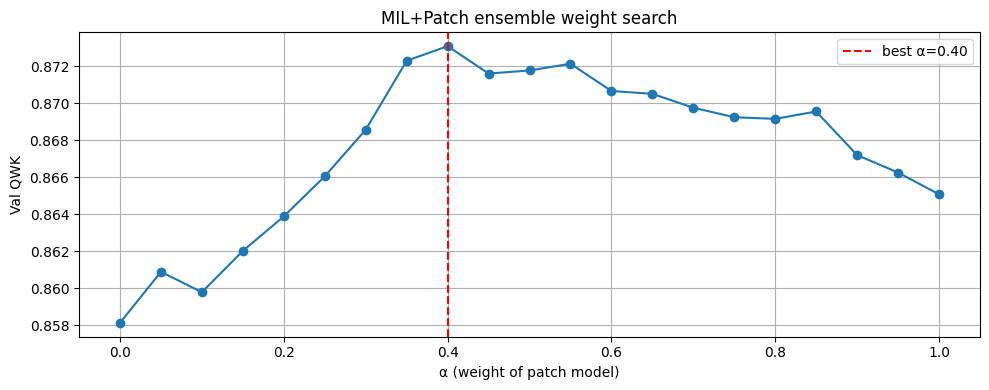

In [7]:
# ── Grid search for optimal weight α on validation set ───────────────
# Ensemble = α * patch_probs + (1-α) * mil_probs
from sklearn.metrics import cohen_kappa_score

best_alpha = 0.5
best_val_kappa = 0.0
alphas = np.arange(0.0, 1.05, 0.05)
kappas = []

for alpha in alphas:
    ensemble_probs = alpha * val_patch_probs + (1 - alpha) * val_mil_probs
    preds = (ensemble_probs > 0.5).sum(axis=1)
    k = cohen_kappa_score(val_targets, preds, weights='quadratic')
    kappas.append(k)
    if k > best_val_kappa:
        best_val_kappa = k
        best_alpha = alpha

print(f'Best α = {best_alpha:.2f}  →  val kappa = {best_val_kappa:.4f}')

plt.figure(figsize=(10, 4))
plt.plot(alphas, kappas, marker='o')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'best α={best_alpha:.2f}')
plt.xlabel('α (weight of patch model)'); plt.ylabel('Val QWK')
plt.title('MIL+Patch ensemble weight search')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('logs/mil-patch-alpha-search.png', dpi=200)
plt.show()

In [8]:
# ── Test set inference ────────────────────────────────────────────────
test_patch_probs, test_targets   = get_patch_probs(patch_model, df_test_common,
                                                   IMAGES_DIR, BATCH_SIZE_PATCH, NUM_WORKERS, DEVICE)
test_mil_probs, test_targets_mil = get_mil_probs(mil_model, df_test_common,
                                                 PATCHES_DIR, BATCH_SIZE_MIL, NUM_WORKERS, DEVICE)

assert np.array_equal(test_targets, test_targets_mil)

MIL inference: 100%|██████████| 199/199 [01:06<00:00,  2.97it/s]


In [ ]:
# ── Compare strategies ────────────────────────────────────────────────
strategies = {
    'Patch-Only':         test_patch_probs,
    'MIL-Only':           test_mil_probs,
    'Ensemble-Mean':      0.5  * test_patch_probs + 0.5  * test_mil_probs,
    f'Ensemble-α={best_alpha:.2f}': best_alpha * test_patch_probs + (1 - best_alpha) * test_mil_probs,
}

results = {}
for name, probs in strategies.items():
    preds = (probs > 0.5).sum(axis=1)
    m = calculate_metrics(preds, test_targets)
    results[name] = m


MIL + Patch Ensemble — Test Set Comparison
Model                            Kappa (mean)      Std               95% CI      Acc       F1
------------------------------------------------------------------------------------------


KeyError: 'val_acc'

In [13]:
# print(results)
print('\n' + '='*90)
print('MIL + Patch Ensemble — Test Set Comparison')
print('='*90)
print(f'{"Model":<30} {"Kappa (mean)":>14} {"Std":>8} {"95% CI":>20} {"Acc":>8} {"F1":>8}')
print('-'*90)
for name, m in results.items():
    k = m['kappa']; a = m['accuracy']; f = m['f1_macro']
    print(f'{name:<30} {k["mean"]:>14.4f} {k["std"]:>8.4f} '
          f'[{k["ci_5"]:.4f}, {k["ci_95"]:.4f}]  {a["mean"]:>8.4f} {f["mean"]:>8.4f}')


MIL + Patch Ensemble — Test Set Comparison
Model                            Kappa (mean)      Std               95% CI      Acc       F1
------------------------------------------------------------------------------------------
Patch-Only                             0.8590   0.0116 [0.8403, 0.8771]    0.6809   0.6163
MIL-Only                               0.8446   0.0122 [0.8239, 0.8638]    0.6619   0.6046
Ensemble-Mean                          0.8663   0.0115 [0.8464, 0.8839]    0.6992   0.6379
Ensemble-α=0.40                        0.8671   0.0117 [0.8472, 0.8854]    0.7053   0.6472


In [ ]:
# ── Save results ─────────────────────────────────────────────────────
best_strategy = max(results, key=lambda k: results[k]['kappa']['mean'])
best_probs    = strategies[best_strategy]
best_preds    = (best_probs > 0.5).sum(axis=1)

with open('logs/mil-patch-ensemble-test-results.txt', 'w') as f:
    f.write('MIL + Patch-Level Ensemble — Test Results\n')
    f.write('=' * 70 + '\n\n')
    for name, m in results.items():
        f.write(f'=== {name} ===\n')
        f.write(format_metrics(m) + '\n\n')
    f.write(f'Best strategy: {best_strategy}\n\n')
    f.write('Classification Report (best):\n')
    f.write(classification_report(test_targets, best_preds,
                                  target_names=[f'ISUP {i}' for i in range(6)]))
    cm = confusion_matrix(test_targets, best_preds)
    f.write('\nConfusion Matrix:\n' + str(cm))
print(f'Saved → logs/mil-patch-ensemble-test-results.txt  (best: {best_strategy})')

In [ ]:
cm      = confusion_matrix(test_targets, best_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
labels  = [f'ISUP {i}' for i in range(6)]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'MIL+Patch ({best_strategy}) — Normalised Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('logs/mil-patch-ensemble-confusion-matrix-normalized.png', dpi=300)
plt.show()